In [6]:
from sionna.rt import load_scene, RadioMapSolver
from pathlib import Path
import json
import sys

# Add parent directory to path to import from src/
sys.path.append(str(Path(__file__).parent.parent) if '__file__' in globals() else str(Path.cwd().parent))

from src.base_station import set_tx_antenna_array, add_base_station
from src.user_equipment import set_rx_antenna_array

In [7]:
BS_HEIGHT_OFFSET = 30
scene_dir = Path("../scenes/boston_downtown_lidar/")
scene_xml_path = scene_dir / "scene.xml"
building_positions_path = scene_dir / "buildings.json"

In [8]:
def load_building_positions(building_positions_path):
    with open(building_positions_path, 'r') as f:
        return json.load(f)

def get_highest_building_centroid(building_positions):
    """
    Find the building with the highest centroid z-coordinate.
    
    Args:
        building_positions: Dictionary of building data from buildings.json
        
    Returns:
        tuple: (building_id, centroid) where centroid is [x, y, z]
    """
    if not building_positions:
        return None, None
    
    highest_building_id = None
    highest_centroid = None
    max_z = float('-inf')
    
    for building_id, data in building_positions.items():
        centroid = data['centroid']
        z_coord = centroid[2]  # z is at index 2
        
        if z_coord > max_z:
            max_z = z_coord
            highest_building_id = building_id
            highest_centroid = centroid
    
    return highest_building_id, highest_centroid

In [9]:
scene = load_scene(scene_xml_path)
building_positions = load_building_positions(building_positions_path)
building_id, centroid = get_highest_building_centroid(building_positions)

2025-11-27 02:19:39 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


In [10]:
set_tx_antenna_array(
    scene,
    num_rows=8,
    num_cols=8,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="cross")

add_base_station(
    scene,
    "BS_0",
    position=[centroid[0], centroid[1], centroid[2] + BS_OFFSET], # BS is located at the highest building with some offset
    num_sectors=6,  # 8x8 requires many sectors to cover all directions
    mechanical_tilt=10.0,  # Mechanical tilt of the antenna
    azimuth_offset=0.0,  # Azimuth offset of the antenna for the first sector
    tx_power_dbm=43.0,
    display_radius=20.0
)

set_rx_antenna_array(
    scene,
    num_rows=2,
    num_cols=2,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="hw_dipole",
    polarization="VH"
)

Antenna Array Configuration Set:
  - Array: 8x8 (128 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [15.3]°


NameError: name 'BS_OFFSET' is not defined

In [11]:
rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(1, 1),      # Resolution of the radio map
               center=[0, 0, 0],      # Center of the radio map
               size=[1000, 1000],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

ValueError: Scene has no transmitters

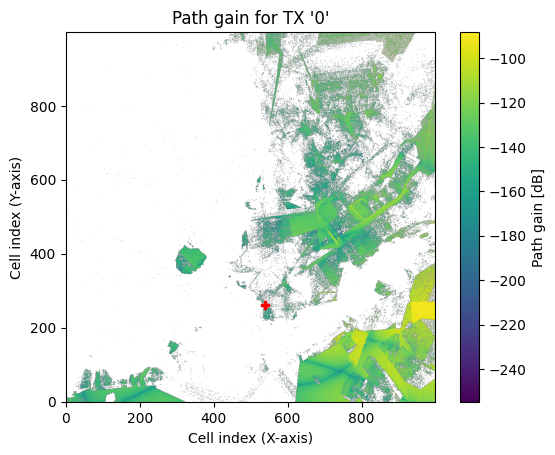

In [18]:
rm.show(metric="path_gain", tx=0);

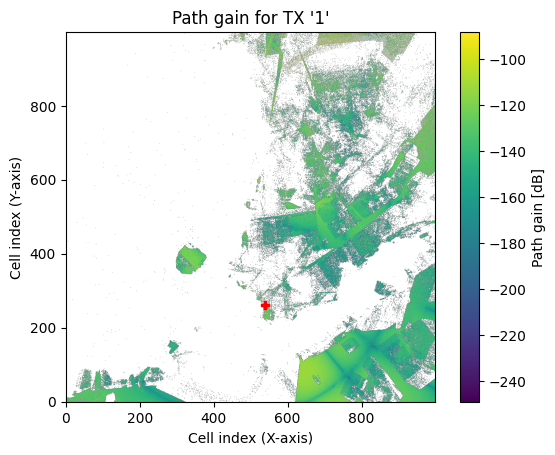

In [19]:
rm.show(metric="path_gain", tx=1);

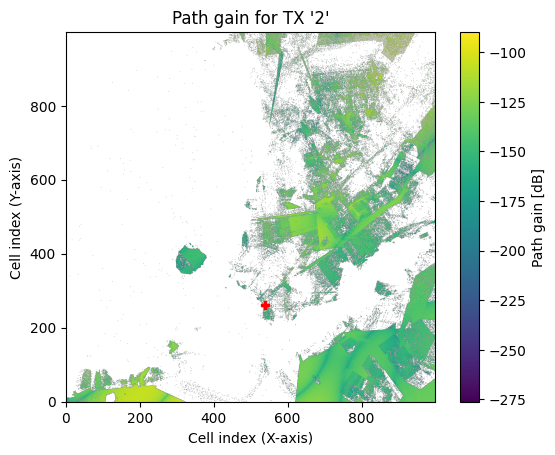

In [20]:
rm.show(metric="path_gain", tx=2);

In [21]:
scene.preview();